# 🛒 Minería de Datos — Clase 2 Final
## Reglas de Asociación: Apriori + Métricas + Cierre del Curso

Este notebook trabaja el bloque final del syllabus:

# Reglas de asociación

Las reglas de asociación permiten descubrir patrones del tipo:

> Si ocurre A, también suele ocurrir B.

Ejemplo:

> Si un cliente compra pan y jamón, también puede comprar queso.

---

## Objetivo de la clase

Comprender cómo descubrir asociaciones frecuentes en datos transaccionales.

---

## Temas de la clase

1. Qué son reglas de asociación.
2. Qué es market basket analysis.
3. Qué es soporte.
4. Qué es confianza.
5. Qué es lift.
6. Qué es leverage.
7. Algoritmo Apriori.
8. Generación e interpretación de reglas.
9. Filtrado de reglas útiles.
10. Taller final y cierre del curso.

# 1. ¿Qué son reglas de asociación?

Las reglas de asociación son técnicas de minería de datos usadas para encontrar relaciones frecuentes entre elementos.

Se usan principalmente en datos transaccionales.

---

## Ejemplos

| Contexto | Regla posible |
|---|---|
| Supermercado | Si compra leche, compra cereal |
| E-commerce | Si compra celular, compra forro |
| Educación | Si reprueba cálculo, puede reprobar física |
| Salud | Si presenta síntoma A y B, puede presentar condición C |
| Streaming | Si ve película X, puede ver película Y |

---

## Forma general

\[
A \rightarrow B
\]

Donde:

- `A` es el antecedente.
- `B` es el consecuente.

Ejemplo:

\[
\{pan, jamón\} \rightarrow \{queso\}
\]

# 2. Diferencia con clasificación y clustering

| Técnica | Tiene variable objetivo | Qué busca |
|---|---|---|
| Clasificación | Sí | predecir una clase |
| Regresión | Sí | predecir un valor |
| Clustering | No | agrupar observaciones |
| Reglas de asociación | No | encontrar relaciones frecuentes |

---

## Idea clave

Las reglas de asociación no predicen de la misma forma que un clasificador.

Su objetivo es descubrir patrones interpretables.

# 3. Dataset transaccional

Para esta clase usaremos un dataset pequeño de ejemplo que simula compras en una tienda.

Cada fila representa una transacción.

Cada columna representa un producto.

El valor indica si el producto fue comprado o no.

---

## Formato esperado

| pan | leche | queso | cerveza |
|---|---|---|---|
| 1 | 1 | 0 | 0 |
| 1 | 0 | 1 | 0 |
| 0 | 1 | 1 | 1 |

Este formato se conoce como one-hot encoding transaccional.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 4. Instalación de librería

Usaremos `mlxtend`, una librería común para trabajar con Apriori y reglas de asociación en Python.

En Google Colab normalmente se puede instalar con:

```python
!pip install mlxtend
```

In [2]:
!pip install mlxtend

In [3]:
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 5. Crear dataset de transacciones

Vamos a construir una base de datos de compras.

Cada transacción representa productos comprados por un cliente.

In [4]:
transacciones = [
    ["pan", "leche", "queso"],
    ["pan", "leche"],
    ["pan", "queso"],
    ["leche", "queso"],
    ["pan", "leche", "queso", "huevos"],
    ["pan", "cerveza"],
    ["cerveza", "papas"],
    ["pan", "leche", "huevos"],
    ["leche", "queso", "huevos"],
    ["pan", "queso", "huevos"],
    ["pan", "leche", "queso"],
    ["leche", "huevos"],
    ["pan", "leche", "cerveza"],
    ["pan", "papas", "cerveza"],
    ["queso", "huevos"],
    ["pan", "leche", "queso", "huevos"],
    ["pan", "leche"],
    ["leche", "queso"],
    ["pan", "queso"],
    ["pan", "leche", "queso", "papas"]
]

transacciones

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[['pan', 'leche', 'queso'],
 ['pan', 'leche'],
 ['pan', 'queso'],
 ['leche', 'queso'],
 ['pan', 'leche', 'queso', 'huevos'],
 ['pan', 'cerveza'],
 ['cerveza', 'papas'],
 ['pan', 'leche', 'huevos'],
 ['leche', 'queso', 'huevos'],
 ['pan', 'queso', 'huevos'],
 ['pan', 'leche', 'queso'],
 ['leche', 'huevos'],
 ['pan', 'leche', 'cerveza'],
 ['pan', 'papas', 'cerveza'],
 ['queso', 'huevos'],
 ['pan', 'leche', 'queso', 'huevos'],
 ['pan', 'leche'],
 ['leche', 'queso'],
 ['pan', 'queso'],
 ['pan', 'leche', 'queso', 'papas']]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 6. Convertir transacciones a formato one-hot

Apriori necesita una tabla donde:

- cada fila sea una transacción,
- cada columna sea un producto,
- el valor sea `True` si el producto aparece en la transacción y `False` si no aparece.

In [5]:
productos = sorted(list(set(item for trans in transacciones for item in trans)))

df = pd.DataFrame(False, index=range(len(transacciones)), columns=productos)

for i, trans in enumerate(transacciones):
    for item in trans:
        df.loc[i, item] = True

df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,cerveza,huevos,leche,pan,papas,queso
0,False,False,True,True,False,True
1,False,False,True,True,False,False
2,False,False,False,True,False,True
3,False,False,True,False,False,True
4,False,True,True,True,False,True
5,True,False,False,True,False,False
6,True,False,False,False,True,False
7,False,True,True,True,False,False
8,False,True,True,False,False,True
9,False,True,False,True,False,True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 7. Frecuencia de productos

Antes de aplicar Apriori revisamos qué productos aparecen con mayor frecuencia.

In [6]:
frecuencia_productos = df.sum().sort_values(ascending=False)

frecuencia_productos

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0
pan,14
leche,13
queso,12
huevos,7
cerveza,4
papas,3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

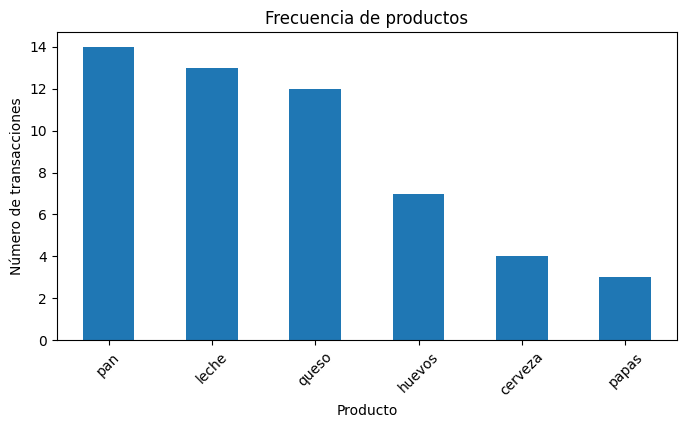

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
plt.figure(figsize=(8,4))
frecuencia_productos.plot(kind="bar")
plt.title("Frecuencia de productos")
plt.xlabel("Producto")
plt.ylabel("Número de transacciones")
plt.xticks(rotation=45)
plt.show()

# 8. Métrica 1: Soporte

El soporte mide qué tan frecuente aparece un itemset en el total de transacciones.

\[
support(A)=\frac{\text{transacciones que contienen A}}{\text{total de transacciones}}
\]

---

## Interpretación

Si:

\[
support(\{pan\}) = 0.70
\]

significa que el pan aparece en el 70% de las transacciones.

---

## Soporte de una regla

Para una regla:

\[
A \rightarrow B
\]

el soporte mide qué proporción de transacciones contienen A y B juntos.

# 9. Algoritmo Apriori

Apriori busca conjuntos frecuentes de productos.

La idea se basa en una propiedad importante:

> Si un conjunto de productos no es frecuente, entonces ningún superconjunto que lo contenga será frecuente.

Ejemplo:

Si `{pan, queso}` no es frecuente, entonces `{pan, queso, huevos}` tampoco debería ser frecuente.

Esto permite reducir la búsqueda.

In [8]:
itemsets_frecuentes = apriori(
    df,
    min_support=0.20,
    use_colnames=True
)

itemsets_frecuentes.sort_values("support", ascending=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
3,0.70,(pan)
2,0.65,(leche)
4,0.60,(queso)
8,0.45,"(pan, leche)"
9,0.40,"(queso, leche)"
10,0.40,"(queso, pan)"
1,0.35,(huevos)
5,0.25,"(leche, huevos)"
11,0.25,"(queso, pan, leche)"
7,0.25,"(queso, huevos)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 10. Interpretación de itemsets frecuentes

Cada fila representa un conjunto de productos frecuente.

Columnas:

- `support`: proporción de transacciones donde aparece el conjunto.
- `itemsets`: conjunto de productos.

Un itemset frecuente no es todavía una regla.

Primero encontramos patrones frecuentes; luego generamos reglas.

# 11. Métrica 2: Confianza

La confianza mide qué tan probable es encontrar B cuando A ya ocurrió.

\[
confidence(A \rightarrow B)=\frac{support(A \cup B)}{support(A)}
\]

---

## Interpretación

Si:

\[
confidence(\{pan\} \rightarrow \{leche\}) = 0.75
\]

significa que, entre quienes compraron pan, el 75% también compró leche.

---

## Advertencia

Una confianza alta no siempre significa una regla interesante.

Puede ser alta simplemente porque el consecuente es muy común.

# 12. Métrica 3: Lift

Lift compara la probabilidad observada con la esperada si A y B fueran independientes.

\[
lift(A \rightarrow B)=\frac{confidence(A \rightarrow B)}{support(B)}
\]

---

## Interpretación

| Lift | Interpretación |
|---|---|
| lift > 1 | asociación positiva |
| lift = 1 | independencia |
| lift < 1 | asociación negativa |

---

## Regla útil

Una regla con lift mayor que 1 suele ser más interesante porque indica que A aumenta la probabilidad de B.

# 13. Métrica 4: Leverage

Leverage mide la diferencia entre la frecuencia observada de A y B juntos y la frecuencia esperada si fueran independientes.

\[
leverage(A \rightarrow B)=support(A \cup B)-support(A)support(B)
\]

---

## Interpretación

- leverage positivo: A y B aparecen juntos más de lo esperado.
- leverage cercano a 0: poca asociación.
- leverage negativo: aparecen juntos menos de lo esperado.

# 14. Generar reglas de asociación

Ahora generamos reglas a partir de los itemsets frecuentes.

Usaremos como criterio mínimo la confianza.

In [9]:
reglas = association_rules(
    itemsets_frecuentes,
    metric="confidence",
    min_threshold=0.5
)

reglas.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(huevos),(leche),0.35,0.65,0.25,0.714286,1.098901,1.0,0.0225,1.225,0.138462,0.333333,0.183673,0.549451
1,(huevos),(pan),0.35,0.70,0.20,0.571429,0.816327,1.0,-0.0450,0.700,-0.257143,0.235294,-0.428571,0.428571
2,(huevos),(queso),0.35,0.60,0.25,0.714286,1.190476,1.0,0.0400,1.400,0.246154,0.357143,0.285714,0.565476
3,(pan),(leche),0.70,0.65,0.45,0.642857,0.989011,1.0,-0.0050,0.980,-0.035714,0.500000,-0.020408,0.667582
4,(leche),(pan),0.65,0.70,0.45,0.692308,0.989011,1.0,-0.0050,0.975,-0.030769,0.500000,-0.025641,0.667582


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 15. Seleccionar columnas importantes

La tabla completa trae muchas columnas.

Nos enfocaremos en:

- antecedents
- consequents
- support
- confidence
- lift
- leverage

In [10]:
columnas = ["antecedents", "consequents", "support", "confidence", "lift", "leverage"]

reglas_resumen = reglas[columnas].sort_values("lift", ascending=False)

reglas_resumen

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift,leverage
2,(huevos),(queso),0.25,0.714286,1.190476,0.0400
0,(huevos),(leche),0.25,0.714286,1.098901,0.0225
6,(leche),(queso),0.40,0.615385,1.025641,0.0100
5,(queso),(leche),0.40,0.666667,1.025641,0.0100
4,(leche),(pan),0.45,0.692308,0.989011,-0.0050
3,(pan),(leche),0.45,0.642857,0.989011,-0.0050
9,"(queso, pan)",(leche),0.25,0.625000,0.961538,-0.0100
7,(queso),(pan),0.40,0.666667,0.952381,-0.0200
8,(pan),(queso),0.40,0.571429,0.952381,-0.0200
11,"(pan, leche)",(queso),0.25,0.555556,0.925926,-0.0200


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 16. Interpretación de una regla

Ejemplo:

\[
\{pan\} \rightarrow \{leche\}
\]

Interpretación:

> Cuando aparece pan en una compra, también tiende a aparecer leche.

Pero para decidir si la regla es útil se revisa:

1. soporte,
2. confianza,
3. lift,
4. leverage.

---

## Regla fuerte

Una regla puede considerarse interesante si:

- tiene soporte razonable,
- confianza alta,
- lift mayor que 1,
- leverage positivo.

# 17. Filtrar reglas útiles

Filtraremos reglas con:

- confidence >= 0.6
- lift > 1

In [11]:
reglas_utiles = reglas[
    (reglas["confidence"] >= 0.6) &
    (reglas["lift"] > 1)
][columnas].sort_values("lift", ascending=False)

reglas_utiles

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift,leverage
2,(huevos),(queso),0.25,0.714286,1.190476,0.0400
0,(huevos),(leche),0.25,0.714286,1.098901,0.0225
5,(queso),(leche),0.40,0.666667,1.025641,0.0100
6,(leche),(queso),0.40,0.615385,1.025641,0.0100


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 18. Convertir reglas a texto legible

Para presentar resultados es útil transformar las reglas a texto.

In [12]:
def regla_a_texto(row):
    antecedente = ", ".join(list(row["antecedents"]))
    consecuente = ", ".join(list(row["consequents"]))
    return f"Si compra {{{antecedente}}}, entonces también tiende a comprar {{{consecuente}}}"

reglas_utiles = reglas_utiles.copy()
reglas_utiles["interpretacion"] = reglas_utiles.apply(regla_a_texto, axis=1)

reglas_utiles[["interpretacion", "support", "confidence", "lift", "leverage"]]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,interpretacion,support,confidence,lift,leverage
2,"Si compra {huevos}, entonces también tiende a ...",0.25,0.714286,1.190476,0.0400
0,"Si compra {huevos}, entonces también tiende a ...",0.25,0.714286,1.098901,0.0225
5,"Si compra {queso}, entonces también tiende a c...",0.40,0.666667,1.025641,0.0100
6,"Si compra {leche}, entonces también tiende a c...",0.40,0.615385,1.025641,0.0100


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 19. Visualización de reglas por lift

Graficamos las reglas más fuertes según lift.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

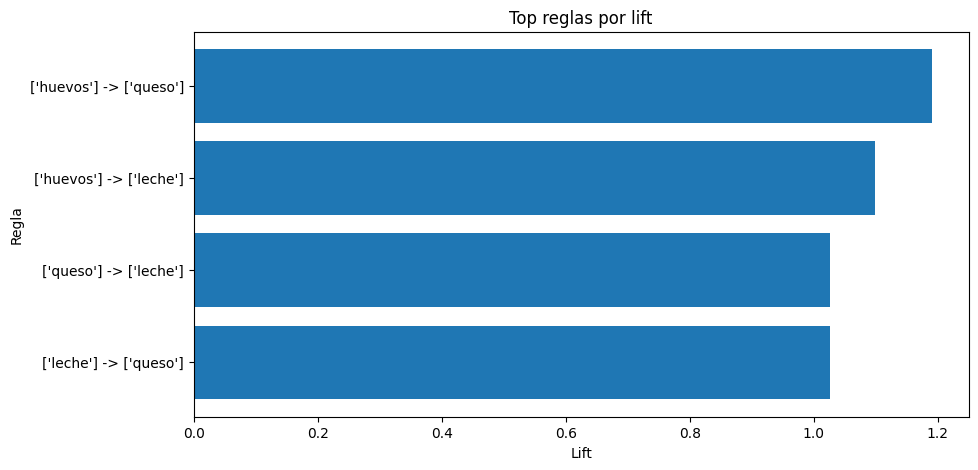

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
top_reglas = reglas_utiles.head(10).copy()

if len(top_reglas) > 0:
    top_reglas["regla"] = top_reglas.apply(
        lambda row: f"{list(row['antecedents'])} -> {list(row['consequents'])}",
        axis=1
    )

    plt.figure(figsize=(10,5))
    plt.barh(top_reglas["regla"], top_reglas["lift"])
    plt.gca().invert_yaxis()
    plt.title("Top reglas por lift")
    plt.xlabel("Lift")
    plt.ylabel("Regla")
    plt.show()
else:
    print("No hay reglas que cumplan los filtros.")

# 20. Visualización: soporte vs confianza

Este gráfico permite analizar reglas de manera conjunta.

- eje X: soporte
- eje Y: confianza
- color/tamaño: lift

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

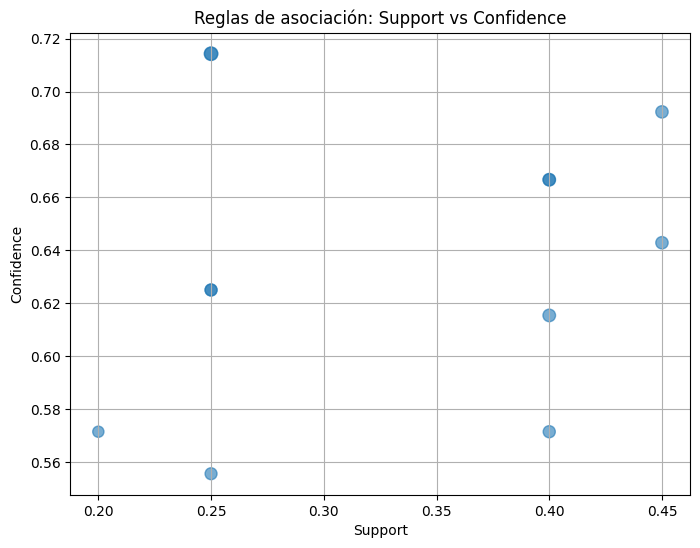

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    reglas["support"],
    reglas["confidence"],
    s=reglas["lift"]*80,
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Reglas de asociación: Support vs Confidence")
plt.grid(True)
plt.show()

# 21. Discusión crítica

Una regla no debe aceptarse solo porque tenga alta confianza.

Ejemplo:

Si un producto es muy común, muchas reglas pueden apuntar a él.

Por eso lift y leverage ayudan a determinar si la asociación es realmente interesante.

---

## Interpretación profesional

Una regla útil debe ser:

1. frecuente,
2. confiable,
3. más fuerte que el azar,
4. accionable.

# 22. Comparación con otros métodos del curso

| Técnica | Objetivo |
|---|---|
| Clasificación | predecir clases |
| Regresión | predecir valores |
| Clustering | descubrir grupos |
| PCA | reducir dimensionalidad |
| Reglas de asociación | descubrir relaciones entre elementos |

---

## Idea clave

Las reglas de asociación son especialmente útiles cuando los datos tienen estructura transaccional.

# 23. Eclat: mención conceptual

El syllabus también menciona Eclat.

Eclat es otro algoritmo para encontrar itemsets frecuentes.

Diferencia principal:

- Apriori trabaja de forma horizontal/transaccional.
- Eclat trabaja con representación vertical de los datos.

En esta clase se implementa Apriori por ser más común y más didáctico.

# 24. Cierre CRISP-DM

Las reglas de asociación también pueden ubicarse dentro de CRISP-DM:

1. **Comprensión del negocio:** ¿qué patrón de compra interesa?
2. **Comprensión de datos:** revisar transacciones.
3. **Preparación:** convertir a one-hot.
4. **Modelado:** Apriori.
5. **Evaluación:** soporte, confianza, lift, leverage.
6. **Despliegue:** recomendaciones, promociones, organización de productos.

---

## Ejemplo de uso real

Si se encuentra una regla:

> Si compra café, compra azúcar.

Una tienda podría:

- ubicar productos cercanos,
- crear promociones,
- recomendar productos,
- diseñar combos.

# 25. Taller final

## Parte A — Conceptos

Responda:

1. ¿Qué es una regla de asociación?
2. ¿Qué es un antecedente?
3. ¿Qué es un consecuente?
4. ¿Qué mide el soporte?
5. ¿Qué mide la confianza?
6. ¿Qué mide el lift?
7. ¿Qué mide el leverage?

---

## Parte B — Implementación

1. Cree un conjunto de al menos 20 transacciones.
2. Conviértalo a formato one-hot.
3. Aplique Apriori.
4. Genere reglas de asociación.
5. Ordene las reglas por lift.

---

## Parte C — Interpretación

Seleccione las 5 mejores reglas y explique:

1. Qué significa la regla.
2. Qué indica su soporte.
3. Qué indica su confianza.
4. Qué indica su lift.
5. Si la regla es accionable o no.

---

## Parte D — Comparación metodológica

Explique la diferencia entre:

1. clasificación,
2. regresión,
3. clustering,
4. PCA,
5. reglas de asociación.

---

## Parte E — Conclusión

Redacte mínimo 10 líneas indicando:

1. qué patrones encontró,
2. cuáles reglas fueron más interesantes,
3. qué métrica usó para decidir,
4. qué limitaciones tiene el análisis,
5. qué decisión de negocio podría tomarse.

# 26. Rúbrica sugerida

| Criterio | Puntaje |
|---|---:|
| Comprensión conceptual de reglas | 0.7 |
| Preparación de datos transaccionales | 0.7 |
| Aplicación correcta de Apriori | 0.8 |
| Uso de soporte, confianza, lift y leverage | 1.0 |
| Interpretación de reglas | 1.0 |
| Conclusión técnica y accionable | 0.8 |
| **Total** | **5.0** |

---

# Cierre del curso

Con esta clase se completa el recorrido por las principales familias de minería de datos:

1. Clasificación.
2. Regresión.
3. Clustering.
4. Reducción dimensional.
5. Reglas de asociación.

La minería de datos no consiste solo en aplicar algoritmos.

Consiste en:

> convertir datos en patrones interpretables para tomar decisiones.